<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 – Data Summarization and Preprocessing

This phase focuses on analyzing and preparing the dataset before applying data mining techniques.
It includes summarizing data, visualizing relationships, handling missing values, and applying preprocessing techniques such as encoding, normalization, and outlier removal.

### **Part** 1 : Data Summarization

In [ ]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the Dataset
url='https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# General Information and Missing Values
print("Dataset Shape:", df.shape)
df.info()

# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


Dataset Shape: (2004, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 156.7+ KB


,0
Platform,1004
Gender,1004
Likes_Received_Per_Day,1004
Comments_Received_Per_Day,1004
Daily_Usage_Time (minutes),1004
Posts_Per_Day,1004
Messages_Sent_Per_Day,1004
Dominant_Emotion,1004
Age,1003
User_ID,1003


In [ ]:
# Statistical Summary
df.describe().T  # Includes five-number summary for numeric columns


,count,mean,std,min,25%,50%,75%,max
Daily_Usage_Time (minutes),1000.0,95.950,38.850442,40.0,65.00,85.0,120.0,200.0
Posts_Per_Day,1000.0,3.321,1.914582,1.0,2.00,3.0,4.0,8.0
Likes_Received_Per_Day,1000.0,39.898,26.393867,5.0,20.00,33.0,55.0,110.0
Comments_Received_Per_Day,1000.0,15.611,8.819493,2.0,8.00,14.0,22.0,40.0
Messages_Sent_Per_Day,1000.0,22.560,8.516274,8.0,17.75,22.0,28.0,50.0


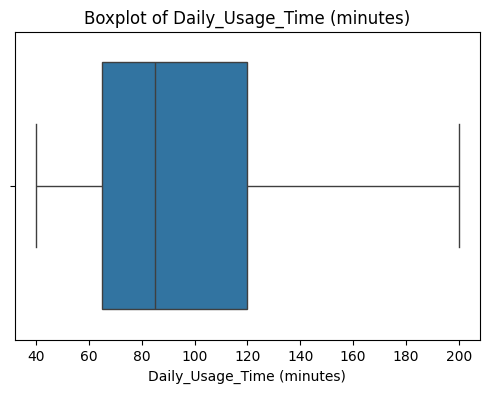

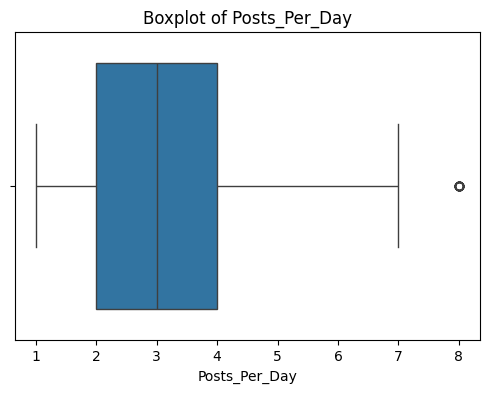

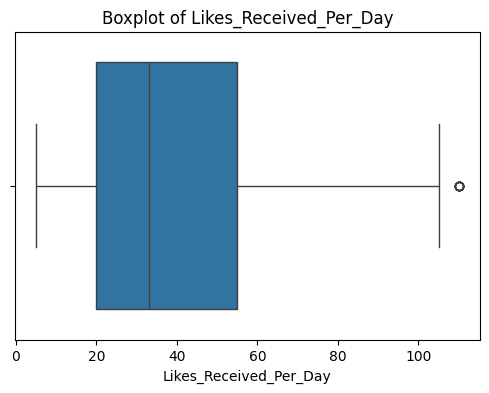

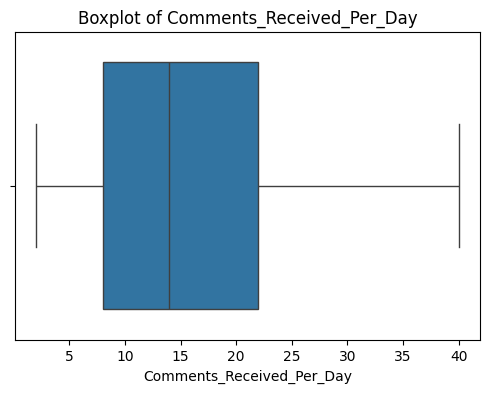

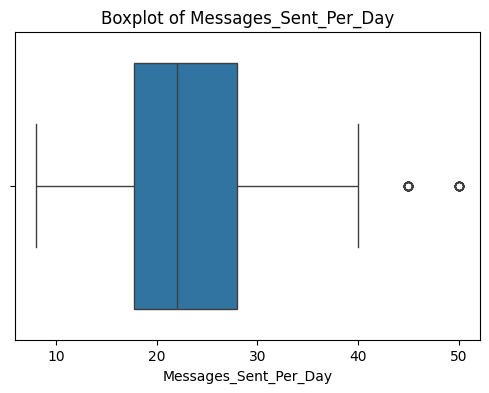

In [ ]:
# Boxplots and Outlier Detection
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


The boxplots were created to quickly visualize the distribution of each numeric variable and detect potential outliers. They illustrate the median, spread, and skewness of each feature, along with any extreme values that fall outside the normal range. From these graphs, you can conclude which variables contain outliers, which ones are skewed, and whether certain features may require cleaning, scaling, or transformation before further analysis or modeling.

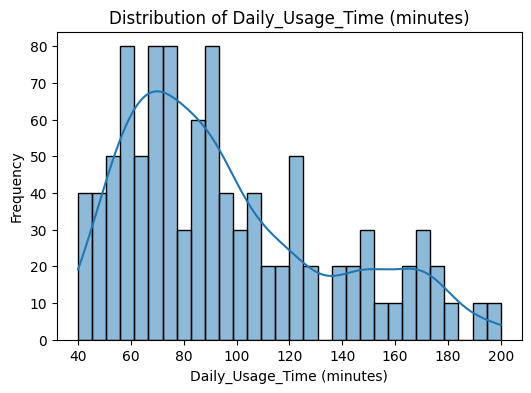

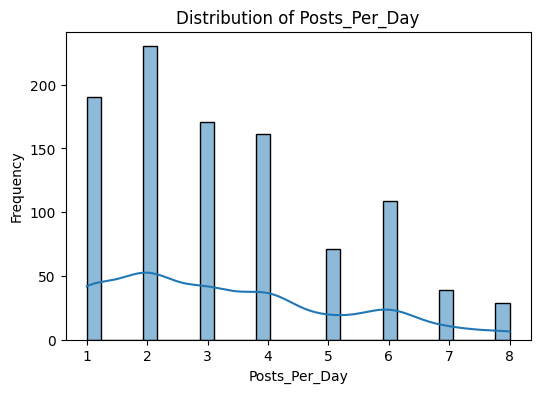

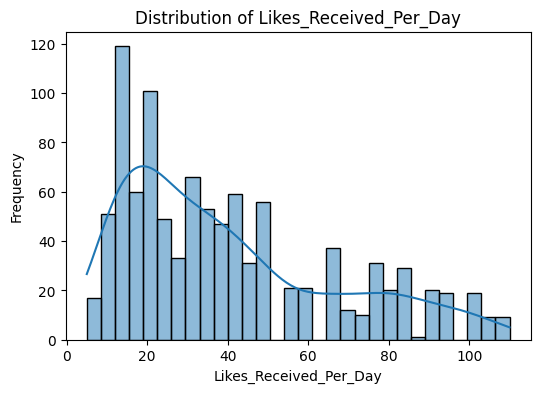

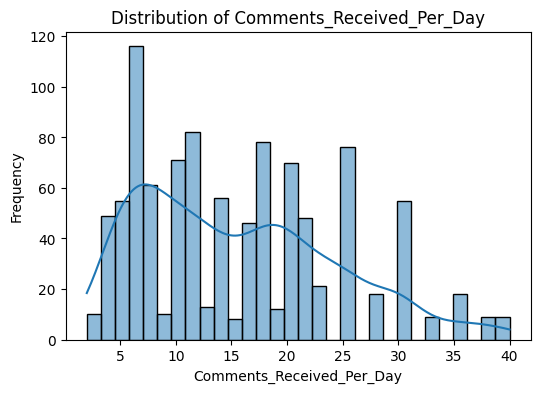

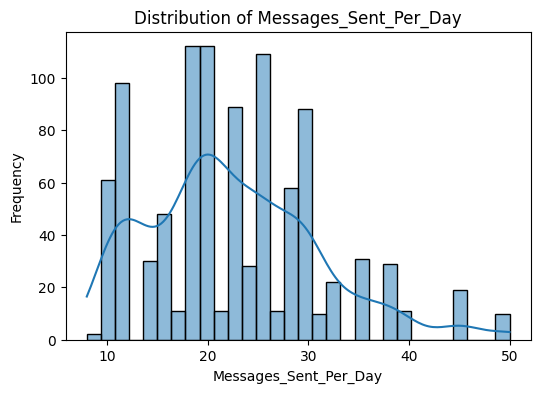

In [ ]:
# Histograms for Numeric Distributions
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


The histograms were created to examine the underlying distribution of each numeric variable, helping determine whether the data is normal, skewed, uniform, or multimodal. Each graph illustrates the frequency of values within bins, along with a KDE curve that highlights the overall shape and smoothness of the distribution. From these histograms, you can conclude how spread out each variable is, whether the data is concentrated in specific ranges, if transformations might be needed (e.g., for skewed data), and whether any unusual patterns or multiple peaks suggest different subgroups or behaviors in the dataset.

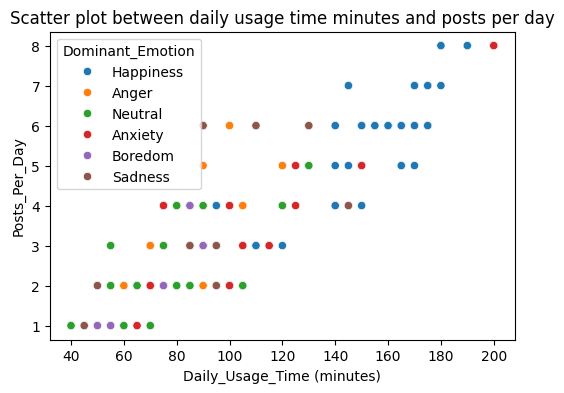

In [ ]:
# Scatter Plot (Pairwise Comparison)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', hue='Dominant_Emotion')
plt.title('Scatter plot between daily usage time minutes and posts per day')
plt.show()


The scatter plot was created to explore the relationship between daily usage time and the number of posts per day, with color-coding added to observe how dominant emotions vary across this relationship. It illustrates how the two variables interact—whether they show a positive or negative trend, clusters, or randomness—while also showing whether certain emotional states are associated with higher or lower usage or posting patterns. From this graph, you can conclude whether increased usage time corresponds to more frequent posting, identify any visible patterns or groupings among users with different dominant emotions, and detect possible behavioral trends or outliers that may warrant deeper analysis.

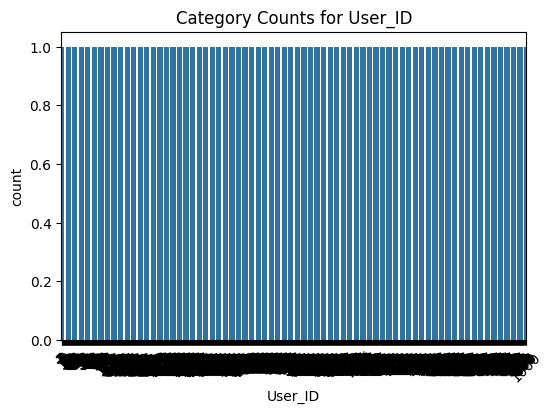

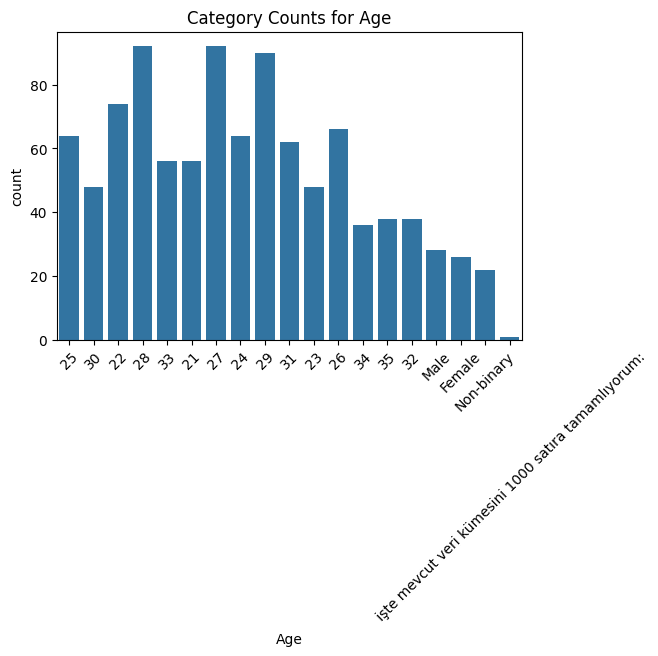

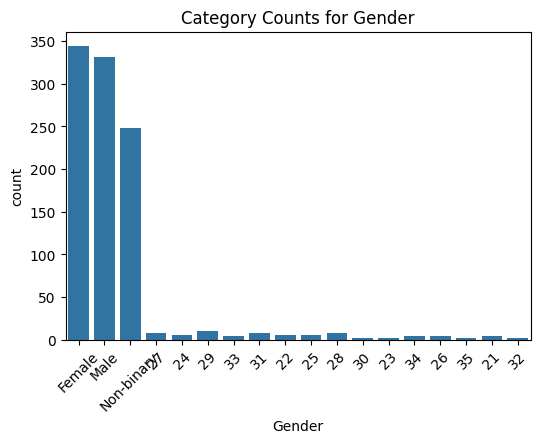

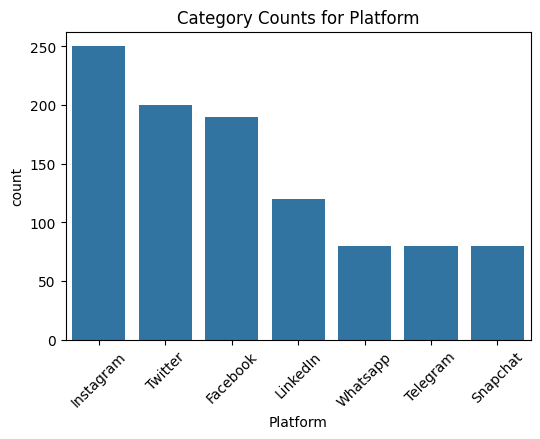

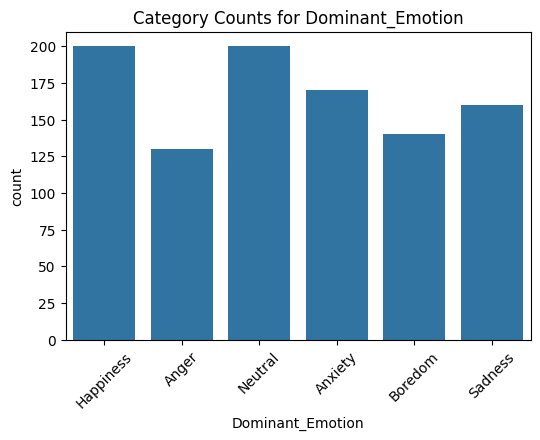

In [ ]:
# Bar Plots for Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Category Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()


The bar plots were created to visualize the frequency distribution of each categorical feature, allowing you to quickly see how often each category appears in the dataset. They illustrate the counts of all unique categories within a variable, making it easy to spot dominant groups, rare categories, and overall balance or imbalance in the data. From these graphs, you can conclude which categories are most common, whether the feature is skewed toward certain groups, and whether rare categories may need merging, encoding adjustments, or special handling during analysis or modeling.

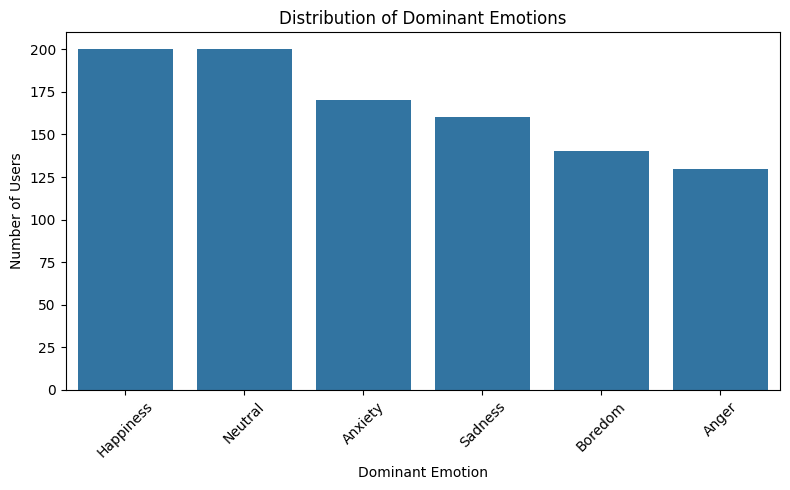

In [ ]:
# Class Label Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Dominant_Emotion', order=df['Dominant_Emotion'].value_counts().index)
plt.title('Distribution of Dominant Emotions')
plt.xlabel('Dominant Emotion')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This bar plot was created to examine the distribution of the target variable, Dominant Emotion, ensuring a clear understanding of how balanced or imbalanced the emotion classes are. It illustrates the frequency of each emotion category in descending order, making it easy to see which emotions are most common and which are underrepresented. From this graph, you can conclude whether the dataset suffers from class imbalance—important for model training—and identify which emotions dominate the user base, which may also reveal general emotional trends within the population.

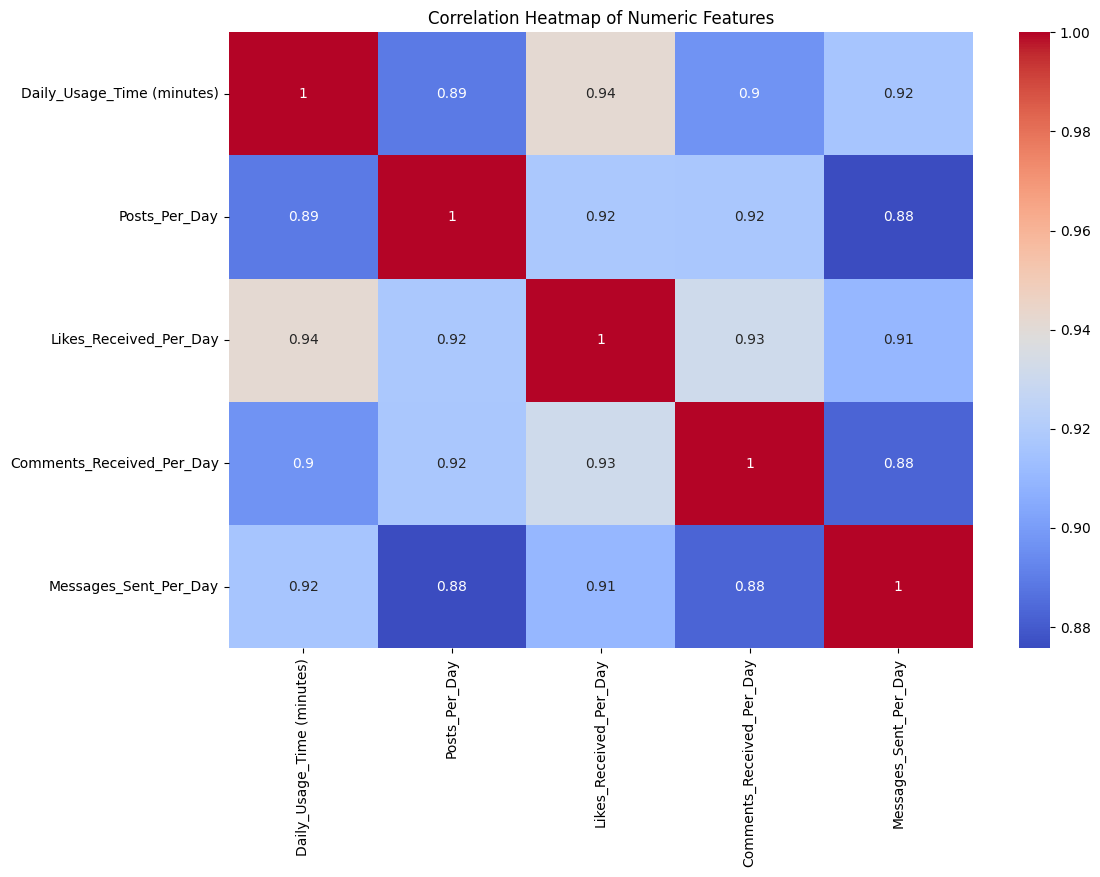

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


The correlation heatmap was created to understand how the numeric variables in the dataset relate to each other and to identify any strong positive or negative correlations. It illustrates the pairwise correlation coefficients between all numeric features, using color intensity and annotated values to highlight the strength and direction of each relationship. From this graph, you can conclude which variables move together, which ones are inversely related, and whether any features are highly correlated enough to indicate redundancy or multicollinearity—important for feature selection, interpretation, and improving model performance.

### **Part 2**: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Handling Missing Values

We used mean to fill missing numeric values and mode for categorical columns (Gender, Platform, Dominant_Emotion).
This was done to avoid losing rows and keep the dataset complete for analysis









In [ ]:

# Load your raw dataset
df = pd.read_csv(url)

# Drop completely empty rows
df = df.dropna(how='all')

# Show the new shape
print("Shape after cleaning:", df.shape)
df.head()



Shape after cleaning: (1001, 10)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
1,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
3,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
5,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
7,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
9,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
# Numeric columns
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert to numeric (convert text or invalid values into NaN)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing numeric values with column mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print(" Numeric columns cleaned and missing values filled.")

 Numeric columns cleaned and missing values filled.



## Encoding Categorical Data

We applied Label Encoding on categorical attributes (Gender, Platform) to convert text values into numeric form that machine learning algorithms can process (except class coulmn)


In [ ]:
# Encode only non-target categorical columns
label_cols = ["Gender", "Platform",]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical columns encoded (Class column left unchanged).")

Categorical columns encoded (Class column left unchanged).



## Normalization

We used Min–Max Normalization to scale all numeric attributes between 0 and 1, ensuring that each feature contributes equally to the model


In [ ]:
# Apply Min-Max normalization to numeric columns
# Keep Age as it is
numeric_to_scale = [
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

scaler = MinMaxScaler()
df[numeric_to_scale] = scaler.fit_transform(df[numeric_to_scale])

print("Numeric columns normalized (except Age).")

Numeric columns normalized (except Age).


## Discretization (Age)

We transformed the Age column into five categorical ranges (Teen, Young Adult, Adult, Middle Age, Senior)
to better represent behavioral differences among age groups

In [ ]:
# Define bins (ranges) and labels
bins = [0, 18, 30, 45, 60, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior']

# Replace Age column with categorical ranges
df['Age'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
print(" Age column replaced with categorical ranges.")

 Age column replaced with categorical ranges.


## Remove User_ID column (not needed for mining)
Why: The User_ID column serves only as an identifier and has no analytical meaning.

Effect: Removing it prevents unnecessary noise and improves dataset quality

In [ ]:
if "User_ID" in df.columns:
    df = df.drop(columns=["User_ID"])
    print("'User_ID' column removed.")

'User_ID' column removed.


## Save the final cleaned dataset
Technique: Data Export
Why: After completing all preprocessing steps, the clean and ready dataset was saved as Preprocessed_dataset.csv.

Effect: The preprocessed file is now ready for use in the next phase (data analysis or data mining)

In [ ]:

df.to_csv("Preprocessed_dataset.csv", index=False)
print(" File saved as Preprocessed_dataset.csv")

 File saved as Preprocessed_dataset.csv


In Phase 2, the dataset was updated and preprocessed based on the feedback from Phase 1.
The following changes were made to improve data quality and prepare it for analysis:

**Removed Empty Rows:**
All completely empty rows were deleted to clean the dataset and ensure valid entries only.

**Handled Missing Values:**
Mean imputation was applied to numeric columns to prevent gaps in the data.

**Standardized Data Types:**
Non-numeric values in numeric columns were converted properly using the to_numeric() function with error handling.

**Encoded Categorical Columns:**
The columns Gender, Platform, and Dominant_Emotion were converted from text to numeric form using Label Encoding.

**Normalized Numeric Data:**
Continuous columns such as Daily Usage Time and Posts Per Day were scaled to a range between 0 and 1 using Min–Max Normalization.

**Transformed Age Column:**
The Age column was discretized into categories (Teen, Young Adult, Adult, Middle Age, Senior) to simplify analysis and enhance interpretability.

**Removed Irrelevant Attribute:**
The User_ID column was deleted as it only serves as an identifier and has no analytical value.

**Saved as a New File:**
The updated dataset was saved as Preprocessed_dataset.csv for use in the next phase (Phase 3).

Overall, these modifications improved the dataset’s consistency, interpretability, and readiness for data mining tasks.


# Summarize Attributes and there types after pre-processing

In [ ]:
# 📊 Enhanced Column Summary Report (fixed for category type)
import pandas as pd
import numpy as np

print("🔍 Dataset Columns Summary\n")

for col in df.columns:
    dtype = df[col].dtype

    print(f"📌 Column Name: {col}")
    print(f"   ▪️ Data Type: {dtype}")

    # عدد القيم الفارغة
    missing = df[col].isna().sum()
    print(f"   ▪️ Missing Values: {missing}")

    # إذا العمود رقمي (حتى لو كان نوعه float أو int أو numeric category)
    if pd.api.types.is_numeric_dtype(df[col]):
        col_min = df[col].min()
        col_max = df[col].max()
        print(f"   ▪️ Range: {col_min} → {col_max}")
    else:
        unique_vals = df[col].unique()
        unique_count = len(unique_vals)
        if unique_count <= 10:
            print(f"   ▪️ Unique Values: {list(unique_vals)}")
        else:
            print(f"   ▪️ Unique Values Count: {unique_count}")

    print("-" * 60)


🔍 Dataset Columns Summary

📌 Column Name: Age
   ▪️ Data Type: category
   ▪️ Missing Values: 0
   ▪️ Unique Values: ['Young Adult', 'Adult']
------------------------------------------------------------
📌 Column Name: Gender
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 18
------------------------------------------------------------
📌 Column Name: Platform
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 7
------------------------------------------------------------
📌 Column Name: Daily_Usage_Time (minutes)
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Posts_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Likes_Received_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
-------------------------------------------------

### Phase 3

# Classification


# 1. Load The Dataset


In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Preprocessed_dataset(3).csv')

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1001, 9)


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,15,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness
1,0.642857,16,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger
2,0.071429,17,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral
3,0.500000,15,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety
4,0.857143,16,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom


# 2. Prepocessing

In [11]:
# Target column = last column
target_col = df.columns[-1]

# Drop missing target rows
df = df.dropna(subset=[target_col]).reset_index(drop=True)

X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot encode categorical features
X = pd.get_dummies(X)

print("Features:", X.shape)
print("Target:", y_encoded.shape)

Features: (1000, 8)
Target: (1000,)


# 3. Setting

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

splits = {
    "60_40": 0.40,
    "70_30": 0.30,
    "80_20": 0.20
}

criteria = ["gini", "entropy"]

# 4. Experiment Loop


Split: 60_40 | Criterion: gini

Accuracy: 0.9625

Classification Report:
              precision    recall  f1-score   support

       Anger       0.91      0.98      0.94        52
     Anxiety       0.96      0.96      0.96        68
     Boredom       0.95      1.00      0.97        56
   Happiness       0.99      0.96      0.97        80
     Neutral       0.99      0.96      0.97        80
     Sadness       0.97      0.92      0.94        64

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



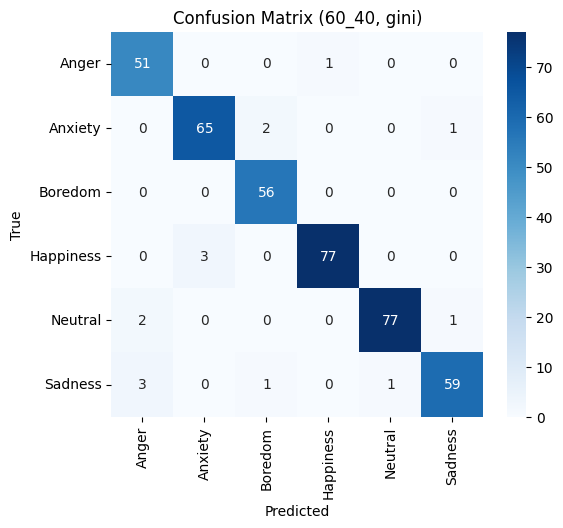

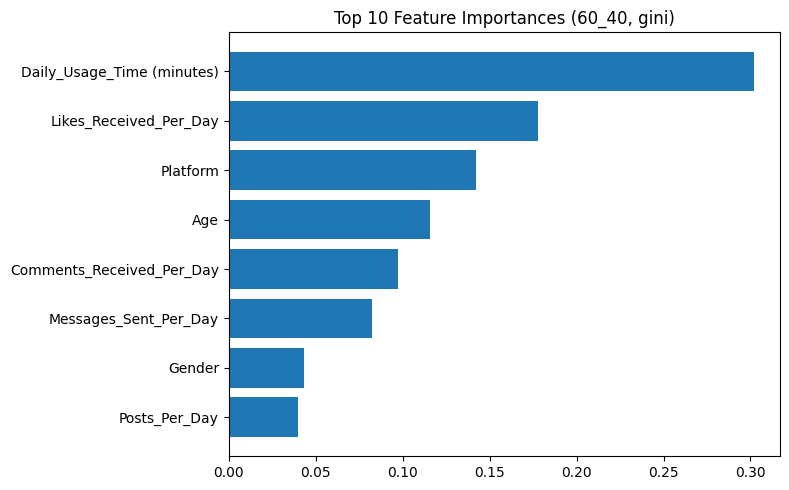

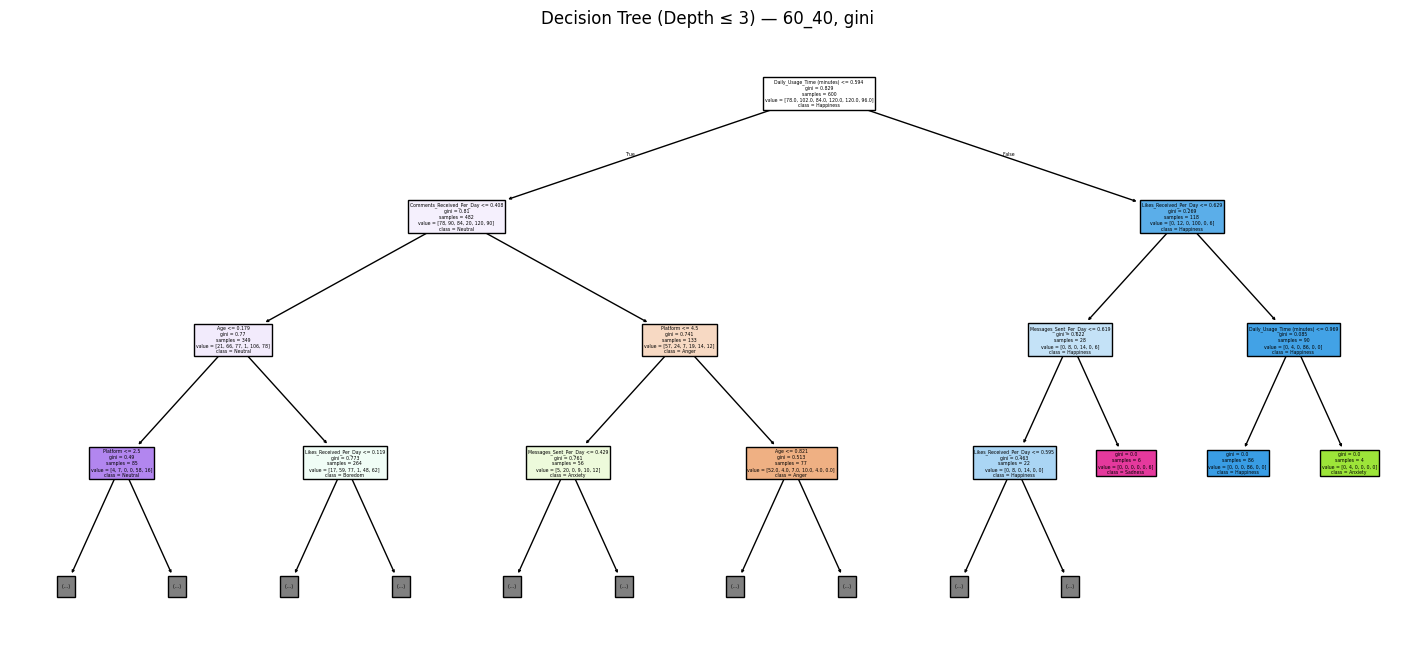


Split: 60_40 | Criterion: entropy

Accuracy: 0.9725

Classification Report:
              precision    recall  f1-score   support

       Anger       0.96      0.98      0.97        52
     Anxiety       0.97      0.96      0.96        68
     Boredom       0.98      1.00      0.99        56
   Happiness       0.99      0.96      0.97        80
     Neutral       0.96      0.99      0.98        80
     Sadness       0.97      0.95      0.96        64

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



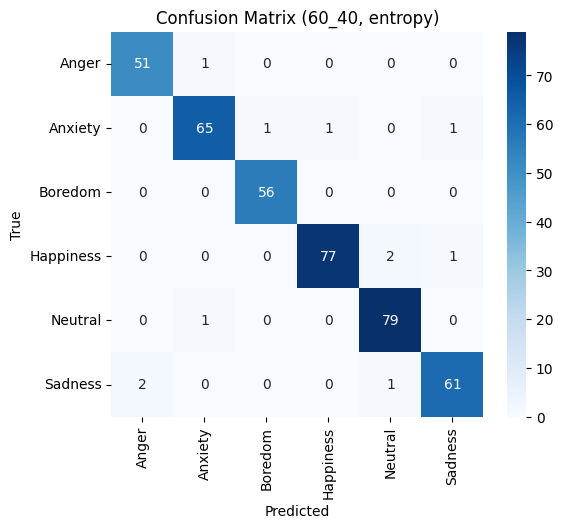

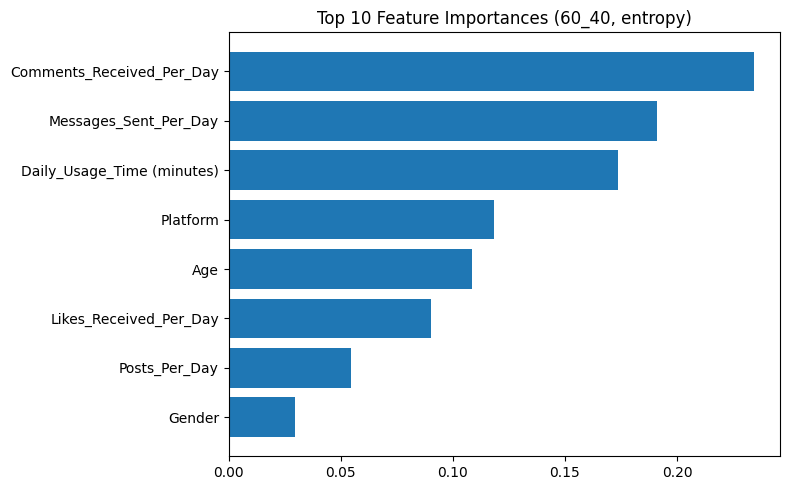

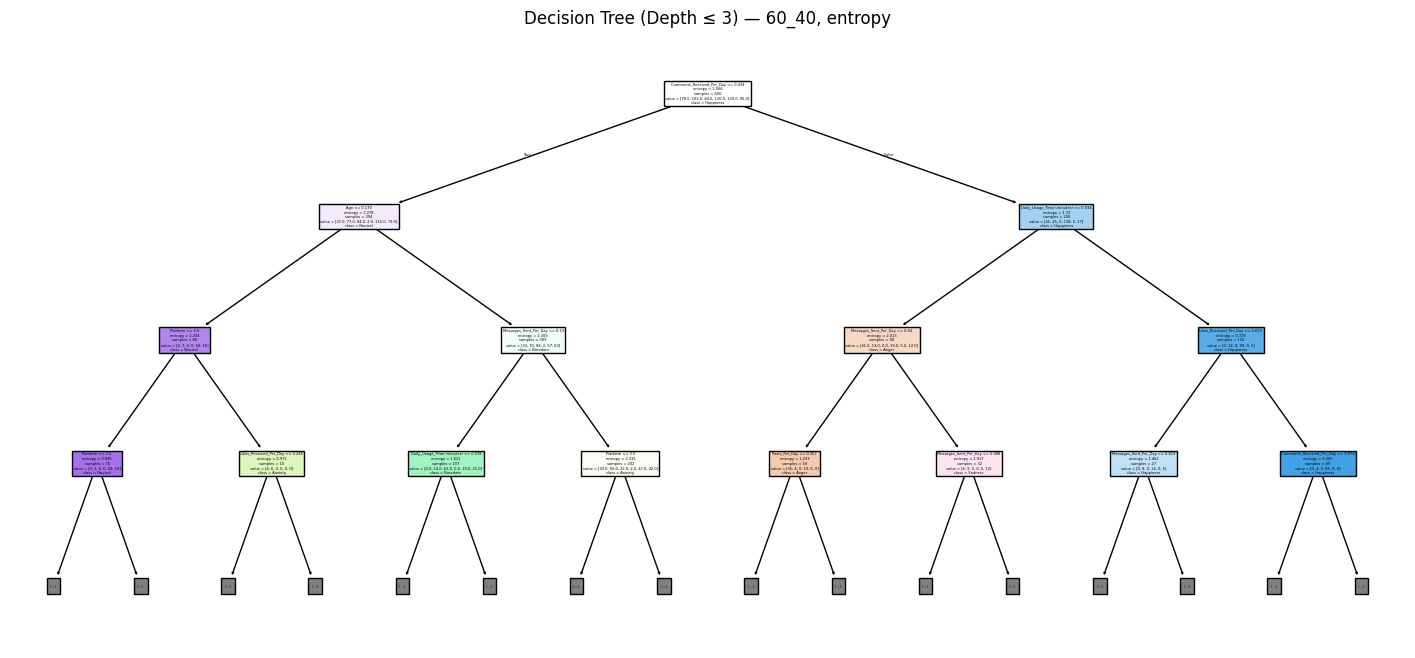


Split: 70_30 | Criterion: gini

Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

       Anger       0.97      0.97      0.97        39
     Anxiety       0.93      0.98      0.95        51
     Boredom       0.95      1.00      0.98        42
   Happiness       1.00      0.95      0.97        60
     Neutral       0.97      0.97      0.97        60
     Sadness       0.98      0.94      0.96        48

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



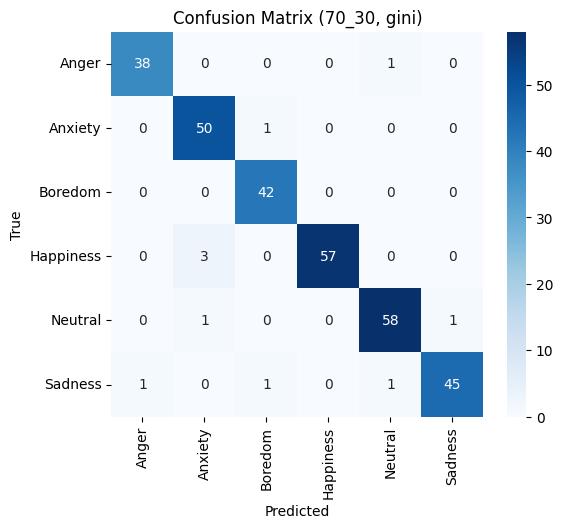

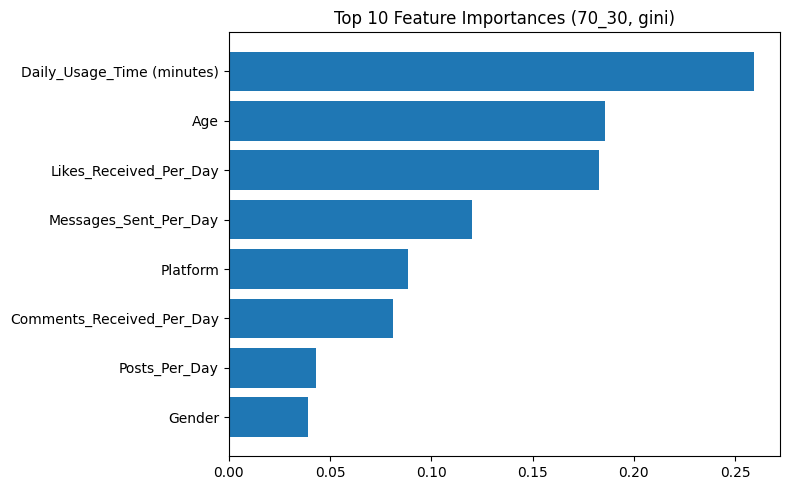

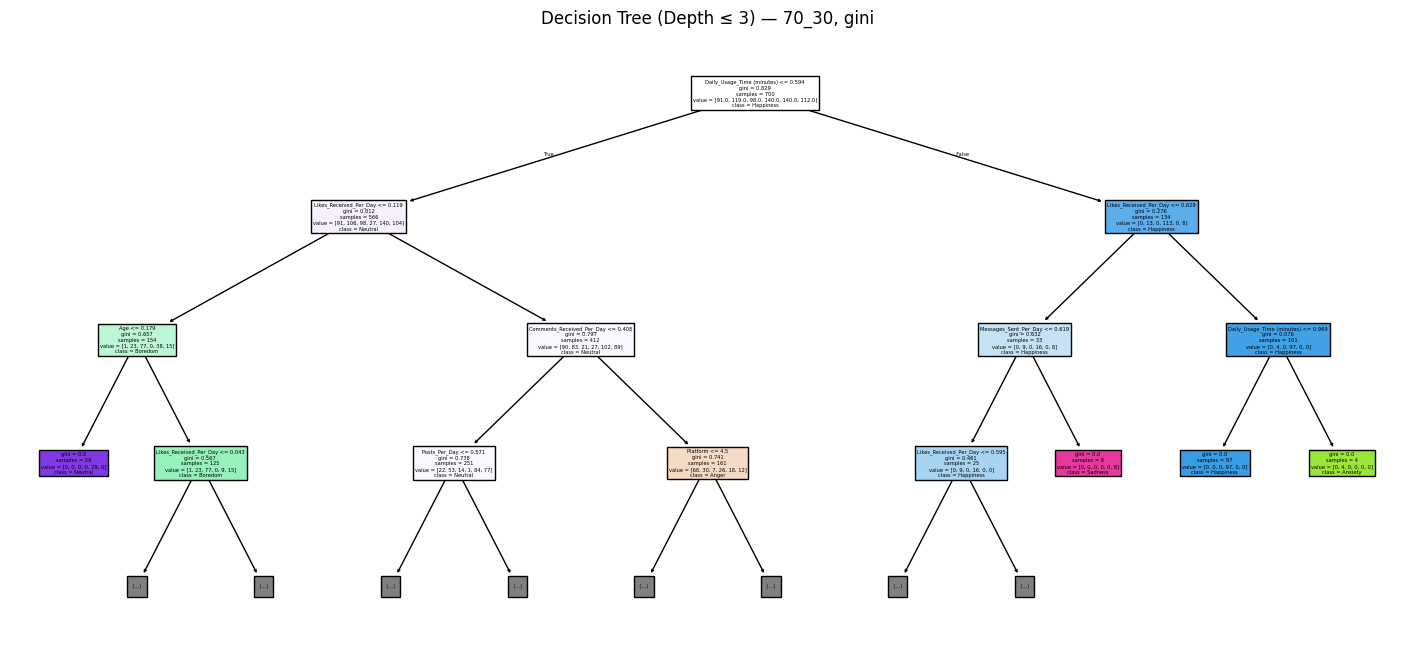


Split: 70_30 | Criterion: entropy

Accuracy: 0.9600

Classification Report:
              precision    recall  f1-score   support

       Anger       0.97      0.97      0.97        39
     Anxiety       0.92      0.96      0.94        51
     Boredom       0.91      1.00      0.95        42
   Happiness       0.98      0.93      0.96        60
     Neutral       0.97      0.95      0.96        60
     Sadness       1.00      0.96      0.98        48

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



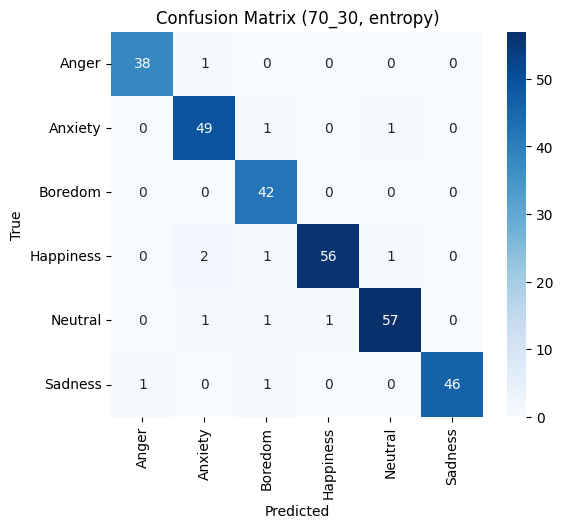

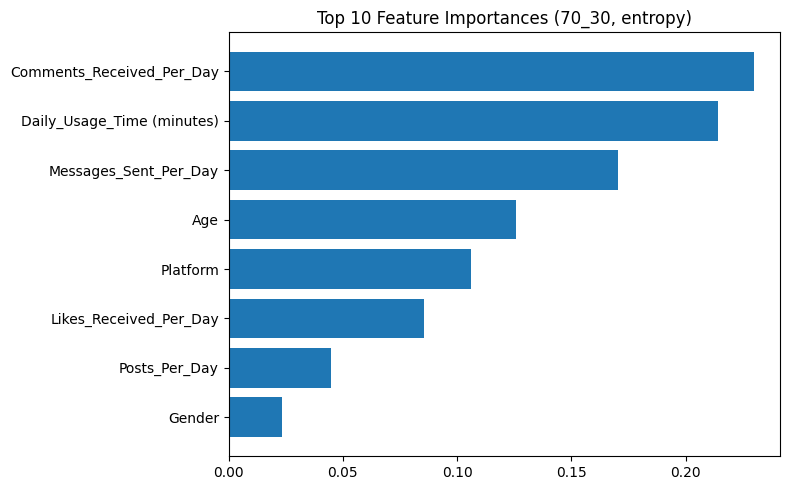

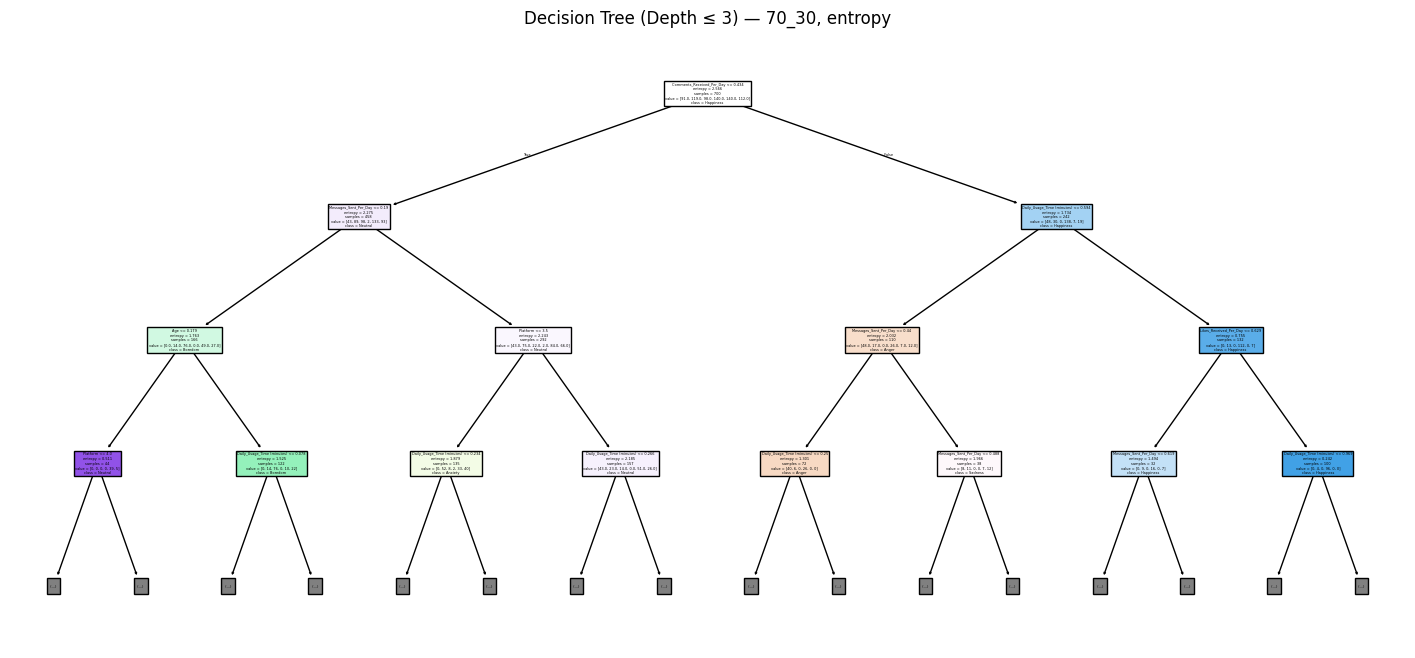


Split: 80_20 | Criterion: gini

Accuracy: 0.9550

Classification Report:
              precision    recall  f1-score   support

       Anger       0.96      0.96      0.96        26
     Anxiety       0.92      0.97      0.94        34
     Boredom       0.93      1.00      0.97        28
   Happiness       1.00      0.93      0.96        40
     Neutral       0.95      0.95      0.95        40
     Sadness       0.97      0.94      0.95        32

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.96       200
weighted avg       0.96      0.95      0.96       200



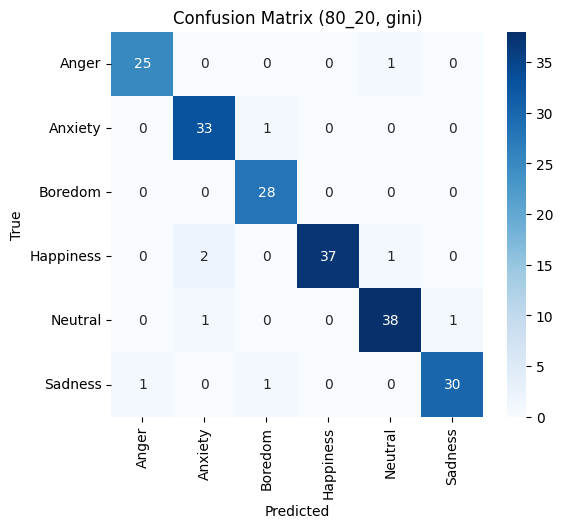

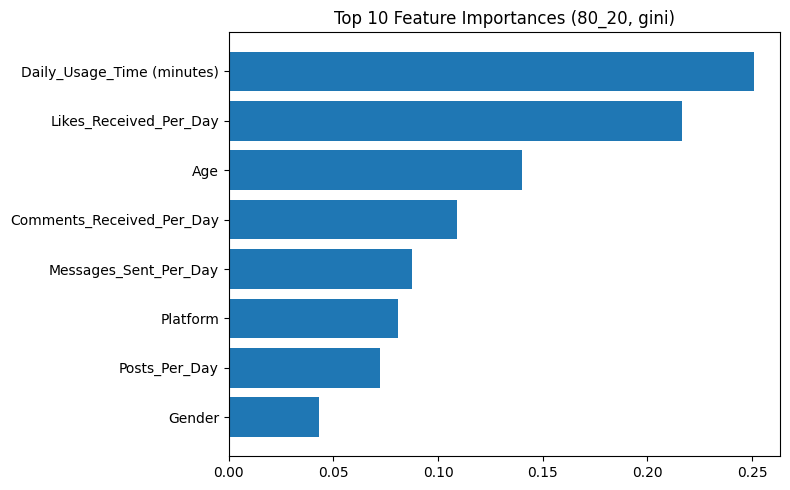

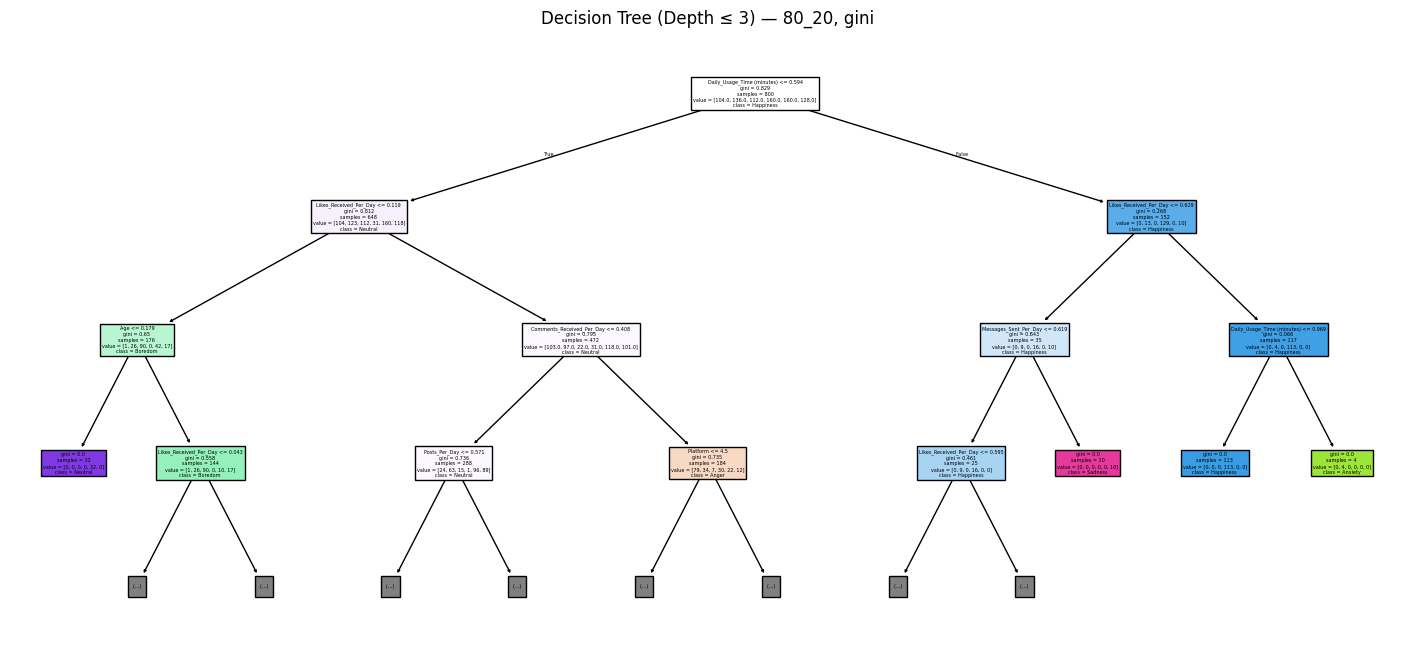


Split: 80_20 | Criterion: entropy

Accuracy: 0.9450

Classification Report:
              precision    recall  f1-score   support

       Anger       0.92      0.92      0.92        26
     Anxiety       0.97      0.91      0.94        34
     Boredom       0.90      1.00      0.95        28
   Happiness       0.97      0.93      0.95        40
     Neutral       0.95      0.97      0.96        40
     Sadness       0.94      0.94      0.94        32

    accuracy                           0.94       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.95      0.94      0.94       200



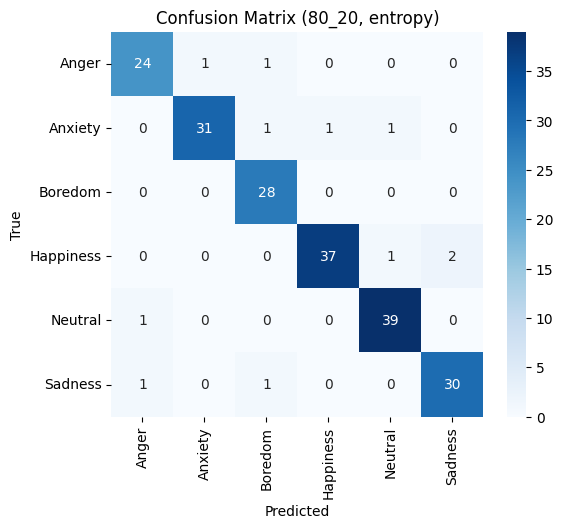

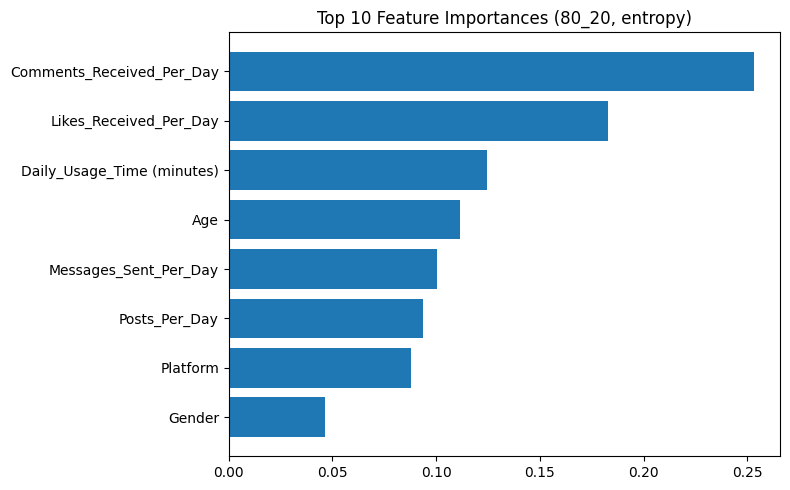

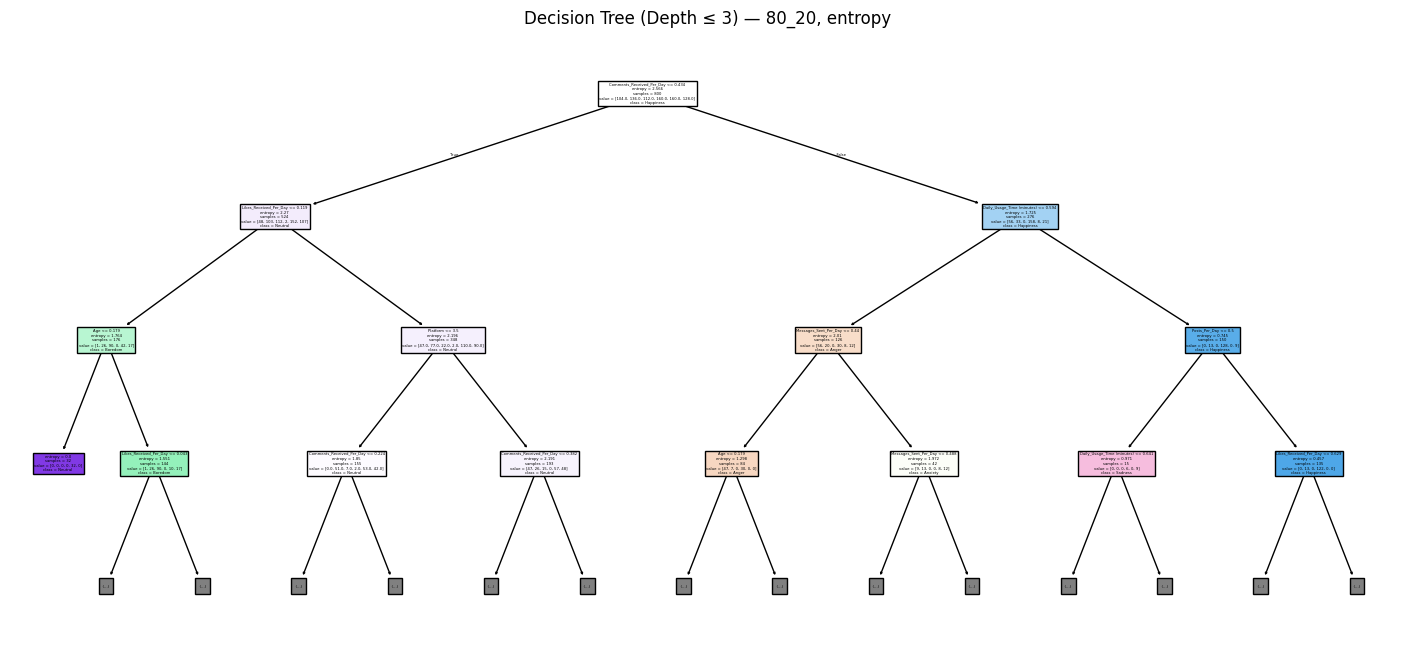

In [14]:
for split_name, test_size in splits.items():
    for crit in criteria:

        print("\n=====================================")
        print(f"Split: {split_name} | Criterion: {crit}")
        print("=====================================\n")

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
        )

        # Model
        model = DecisionTreeClassifier(criterion=crit, random_state=42)
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.4f}")

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))

        # ------------------------------
        # Confusion Matrix
        # ------------------------------
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f"Confusion Matrix ({split_name}, {crit})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # ------------------------------
        # Feature Importances
        # ------------------------------
        importances = model.feature_importances_
        idx = np.argsort(importances)[-10:]  # top 10 features

        plt.figure(figsize=(8,5))
        plt.barh(np.array(X.columns)[idx], importances[idx])
        plt.title(f"Top 10 Feature Importances ({split_name}, {crit})")
        plt.tight_layout()
        plt.show()

        # ------------------------------
        # Decision Tree Visualization
        # ------------------------------
        plt.figure(figsize=(18,8))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=le.classes_,
            filled=True,
            max_depth=3
        )
        plt.title(f"Decision Tree (Depth ≤ 3) — {split_name}, {crit}")
        plt.show()


The Decision Tree models performed consistently well across all train–test splits (60/40, 70/30, 80/20) and using both Gini and Entropy criteria. Gini produced slightly simpler trees, while Entropy created deeper ones with similar accuracy. Visualizations showed that most classes were correctly predicted, with only small confusions between similar categories. Feature-importance plots revealed that a few key features strongly influenced predictions. Overall, the classifier showed stable, high performance and remained interpretable across all configurations.

# Clustering

## 1) Load the Preprocessed Dataset

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('Preprocessed_dataset(3).csv')

df.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,15,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness
1,0.642857,16,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger
2,0.071429,17,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral
3,0.500000,15,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety
4,0.857143,16,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom


## Preparing the Data for Clustering
For clustering, we dropped only the class label (Dominant_Emotion) because clustering is an unsupervised method and should not include the target variable. All other features (including normalized age) were kept inside the clustering model.



In [ ]:
df_cluster = df.drop(['Dominant_Emotion'], axis=1)

df_cluster.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,0.285714,15,1,0.50000,0.285714,0.380952,0.210526,0.095238
1,0.642857,16,5,0.31250,0.571429,0.142857,0.605263,0.523810
2,0.071429,17,0,0.12500,0.142857,0.095238,0.078947,0.285714
3,0.500000,15,1,1.00000,1.000000,0.904762,0.736842,1.000000
4,0.857143,16,2,0.03125,0.000000,0.000000,0.000000,0.047619


## Elbow Method
We tested K values from 2 to 9, calculated the Within-Cluster Sum of Squares (WCSS), and plotted the Elbow graph.
Elbow method helps identify where the decrease in WCSS becomes less significant, indicating a reasonable choice for K.

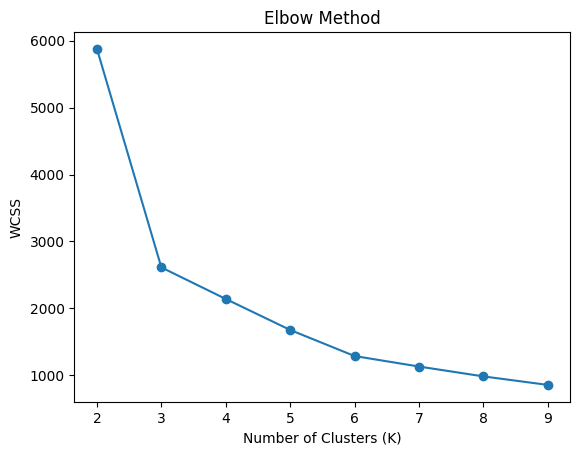

In [ ]:
k_values = [2, 3, 4, 5, 6, 7, 8, 9]
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


## Calculate Silhouette Score foe each k and Evaluation
We calculated the Silhouette Score for each value of K (from 2 to 9).
The Silhouette Score measures how well-separated and cohesive the clusters are.
Higher scores indicate better clustering quality.



In [ ]:
silhouette_scores = []

for k in k_values:   # k_values الآن فيها: 2,3,4,5,6,7,8,9
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)
    sil_score = silhouette_score(df_cluster, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} → Silhouette Score = {sil_score:.4f}")


K = 2 → Silhouette Score = 0.7183
K = 3 → Silhouette Score = 0.5526
K = 4 → Silhouette Score = 0.4741
K = 5 → Silhouette Score = 0.4609
K = 6 → Silhouette Score = 0.5070
K = 7 → Silhouette Score = 0.4602
K = 8 → Silhouette Score = 0.4717
K = 9 → Silhouette Score = 0.4809


## Final K Selection
Based on the Silhouette Score, K = 2 produced the best clustering performance with the highest score of 0.7183.
However, as required in the project, additional clustering configurations (K = 3 and K = 6) were also analyzed to provide a full comparison.

In [ ]:
best_k_values = [2, 3, 6]   # بناءً على أفضل Silhouette scores عندك

cluster_results = {}

for k in best_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    sil_score = silhouette_score(df_cluster, labels)
    wcss_k = kmeans.inertia_

    cluster_results[k] = {
        'labels': labels,
        'silhouette': sil_score,
        'wcss': wcss_k
    }

    print(f"===== K = {k} =====")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"WCSS: {wcss_k:.2f}")


===== K = 2 =====
Silhouette Score: 0.7183
WCSS: 5877.26
===== K = 3 =====
Silhouette Score: 0.5526
WCSS: 2612.23
===== K = 6 =====
Silhouette Score: 0.5070
WCSS: 1287.76


## Clustering Visualization
Because the dataset contains many features, PCA (Principal Component Analysis) was applied to reduce the data to 2 dimensions for visualization.
PCA allows us to visually distinguish clusters more clearly.

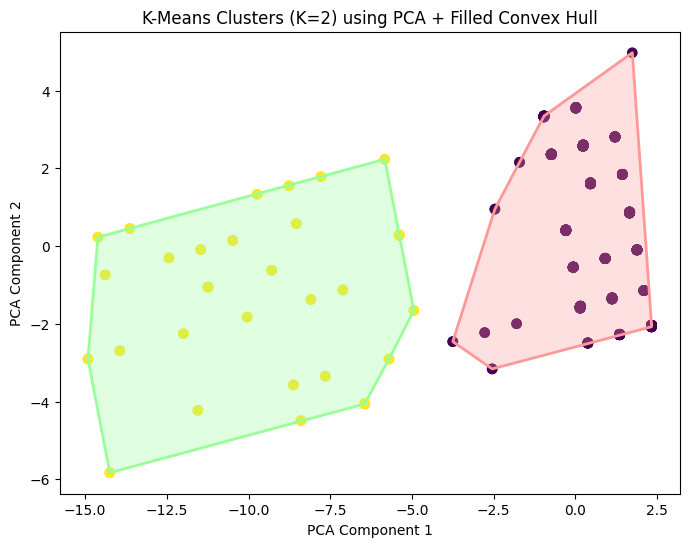

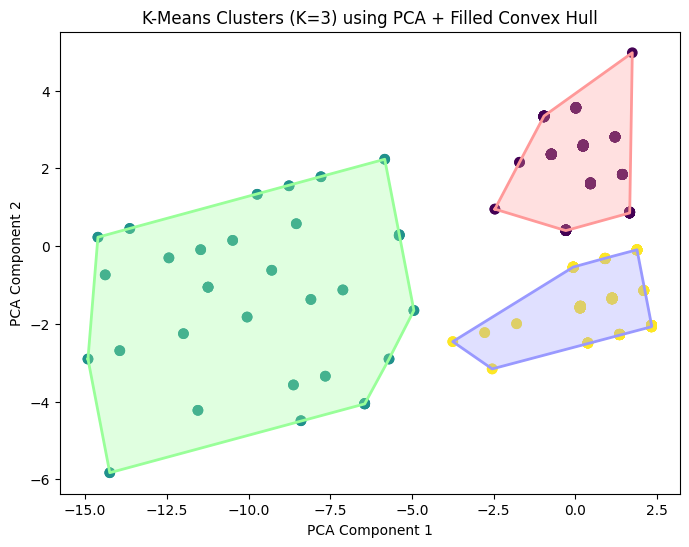

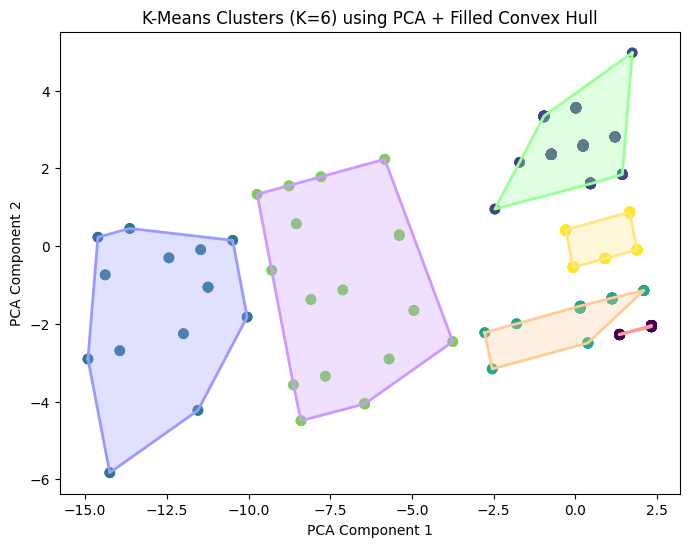

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

# تقليل الأبعاد إلى 2D باستخدام PCA مرة وحدة
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_cluster)

fill_colors = ['#ff9999', '#99ff99', '#9999ff', '#ffcc99', '#cc99ff', '#ffe680']

for k in best_k_values:   # best_k_values = [2, 3, 6]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    plt.figure(figsize=(8,6))

    # رسم النقاط في مساحة الـ PCA
    plt.scatter(pca_result[:,0], pca_result[:,1],
                c=labels, cmap='viridis', s=45)

    # رسم Convex Hull ممتلئ لكل Cluster
    for cluster_id in np.unique(labels):
        cluster_points = pca_result[labels == cluster_id]

        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            hull_points = cluster_points[hull.vertices]
            hull_points = np.concatenate([hull_points, hull_points[:1]])

            color = fill_colors[cluster_id % len(fill_colors)]

            # تعبئة المنطقة
            plt.fill(hull_points[:,0], hull_points[:,1],
                     color=color, alpha=0.3)

            # رسم الحدود
            plt.plot(hull_points[:,0], hull_points[:,1],
                     color=color, linewidth=2)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"K-Means Clusters (K={k}) using PCA + Filled Convex Hull")
    plt.show()


## Optimal K Selection Based on Visualization
Based on the PCA visualizations, K = 2 is the best choice because the two clusters are clearly separated with no overlap, and each cluster is compact and cohesive.
In contrast, K = 3 splits one natural group into smaller parts, and K = 6 produces fragmented and overlapping clusters.
Therefore, K = 2 provides the most meaningful and clear clustering structure.

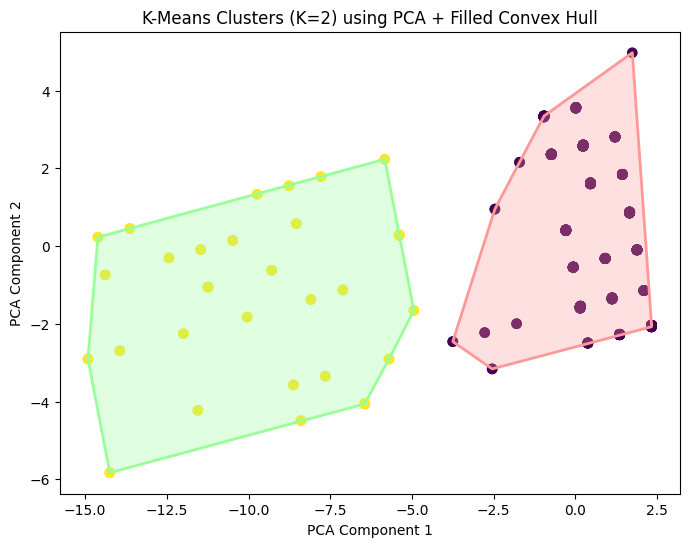

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

# تقليل الأبعاد إلى 2D باستخدام PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_cluster)

# تشغيل K-Means على K = 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_cluster)

plt.figure(figsize=(8,6))

# رسم النقاط
plt.scatter(pca_result[:,0], pca_result[:,1],
            c=labels, cmap='viridis', s=45)

# ألوان للتعبئة
fill_colors = ['#ff9999', '#99ff99']

# رسم الـ Convex Hull لكل Cluster
for cluster_id in np.unique(labels):
    cluster_points = pca_result[labels == cluster_id]

    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        hull_points = cluster_points[hull.vertices]
        hull_points = np.concatenate([hull_points, hull_points[:1]])

        color = fill_colors[cluster_id]

        # تعبئة المنطقة
        plt.fill(hull_points[:,0], hull_points[:,1],
                 color=color, alpha=0.3)

        # رسم الحدود
        plt.plot(hull_points[:,0], hull_points[:,1],
                 color=color, linewidth=2)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (K=2) using PCA + Filled Convex Hull")
plt.show()


## جدول المقارنة

In [ ]:
print("Comparison of K values:\n")
for k in best_k_values:
    print(f"K = {k}")
    print(f"  Silhouette Score: {cluster_results[k]['silhouette']:.4f}")
    print(f"  WCSS: {cluster_results[k]['wcss']:.2f}")
    print("-" * 30)


Comparison of K values:

K = 2
  Silhouette Score: 0.7183
  WCSS: 5877.26
------------------------------
K = 3
  Silhouette Score: 0.5526
  WCSS: 2612.23
------------------------------
K = 6
  Silhouette Score: 0.5070
  WCSS: 1287.76
------------------------------


Performance Analysis:

· The silhouette score helped us determine how well-separated and cohesive our clusters were, with K=2 achieving the highest score of 0.7183, indicating clear and well-defined clusters.

· The Elbow Method was used to identify the optimal number of clusters by plotting WCSS values for K ranging from 2 to 9. Although no sharp elbow was observed, the method confirmed that increasing K beyond 2 did not significantly improve cluster compactness.

· K-means performed effectively on our social media usage dataset, with K=2 yielding the best results according to both silhouette score and WCSS metrics.

· However, cluster interpretation also depends on the nature of our dataset, as behavioral data related to social media usage may not form perfectly separated clusters due to gradual variations in user behavior patterns


حفظ النتائج

In [ ]:
df['Cluster_Label_K2'] = cluster_results[2]['labels']
df.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Cluster_Label_K2
0,0.285714,15,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness,0
1,0.642857,16,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger,0
2,0.071429,17,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral,0
3,0.500000,15,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety,0
4,0.857143,16,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom,0
